# SPTcl IRAC Pointing Map
Author: Benjamin Floyd

This creates a publication plot showing the SPT-SZ and SPTpol 100d footprints along with the targeted IRAC pointing observations.

In [1]:
import ligo.skymap.plot
import matplotlib.pyplot as plt
import numpy as np
from IPython.core.pylabtools import figsize
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack
from astropy.visualization.wcsaxes import Quadrangle
import astropy.units as u
import glob

/opt/miniconda3/envs/astro/lib/python3.11/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
file_names = glob.glob('/Users/ben/Documents/temp_iragn_data/*.tbl')
all_aors = vstack([Table.read(file_name, format='ascii.ipac') for file_name in file_names])

In [3]:
all_aors.colnames

['targetname', 'raj2000', 'decj2000', 'pi', 'progid', 'reqkey', 'reqtitle']

In [4]:
irac_pointing_coords = SkyCoord(all_aors['raj2000'], all_aors['decj2000'], unit='deg')
irac_pointing_coords_c6 = SkyCoord(all_aors['raj2000'][all_aors['progid'] == 60099], all_aors['decj2000'][all_aors['progid'] == 60099], unit='deg')
irac_pointing_coords_c7 = SkyCoord(all_aors['raj2000'][all_aors['progid'] == 70053], all_aors['decj2000'][all_aors['progid'] == 70053], unit='deg')
irac_pointing_coords_c8 = SkyCoord(all_aors['raj2000'][all_aors['progid'] == 80012], all_aors['decj2000'][all_aors['progid'] == 80012], unit='deg')
irac_pointing_coords_c10 = SkyCoord(all_aors['raj2000'][all_aors['progid'] == 10101], all_aors['decj2000'][all_aors['progid'] == 10101], unit='deg')
irac_pointing_coords_c11 = SkyCoord(all_aors['raj2000'][all_aors['progid'] == 11096], all_aors['decj2000'][all_aors['progid'] == 11096], unit='deg')
irac_pointing_coords_c12 = SkyCoord(all_aors['raj2000'][all_aors['progid'] == 12073], all_aors['decj2000'][all_aors['progid'] == 12073], unit='deg')
irac_pointing_coords_c14 = SkyCoord(all_aors['raj2000'][all_aors['progid'] == 14096], all_aors['decj2000'][all_aors['progid'] == 14096], unit='deg')

In [5]:
spt_sz_anchor = SkyCoord(ra=7, dec=-65, unit=(u.hourangle, u.deg))
spt_sz_anchor2 = SkyCoord(ra=20, dec=-65, unit=(u.hourangle, u.deg))
spt_sz_anchor3 = SkyCoord(ra=0, dec=-65, unit=(u.hourangle, u.deg))
spt_sz_anchor, spt_sz_anchor2

(<SkyCoord (ICRS): (ra, dec) in deg
     (105., -65.)>,
 <SkyCoord (ICRS): (ra, dec) in deg
     (300., -65.)>)

In [6]:
sptpol100d_anchor = SkyCoord(ra=23, dec=-60, unit=(u.hourangle, u.deg))
sptpol100d_anchor2 = SkyCoord(ra=0, dec=-60, unit=(u.hourangle, u.deg))
sptpol100d_anchor, sptpol100d_anchor2

(<SkyCoord (ICRS): (ra, dec) in deg
     (345., -60.)>,
 <SkyCoord (ICRS): (ra, dec) in deg
     (0., -60.)>)

In [7]:
spt_sz_width = (spt_sz_anchor2.ra.deg - spt_sz_anchor3.ra.deg)*np.cos(spt_sz_anchor.dec.rad) + (spt_sz_anchor.ra.deg - spt_sz_anchor3.ra.deg)*np.cos(spt_sz_anchor.dec.rad)
sptpol100d_width = (sptpol100d_anchor2.ra.deg - sptpol100d_anchor.ra.deg) * np.cos(sptpol100d_anchor.dec.rad)
sptpol100d_width

-172.5

In [8]:
sptpol100d_width = sptpol100d_anchor.separation(sptpol100d_anchor2).deg

In [9]:
mollweide_opts = dict(projection='astro hours mollweide', center='1h30m 0d')
aitoff_opts = dict(projection='astro hours aitoff', center='1h30m 0d')
globe_opts = dict(projection='astro hours globe', center='1h30m -60d', rotate=180 * u.deg)
zoom_opts = dict(projection='astro hours zoom', center='1h30m -55d', radius='60 deg')

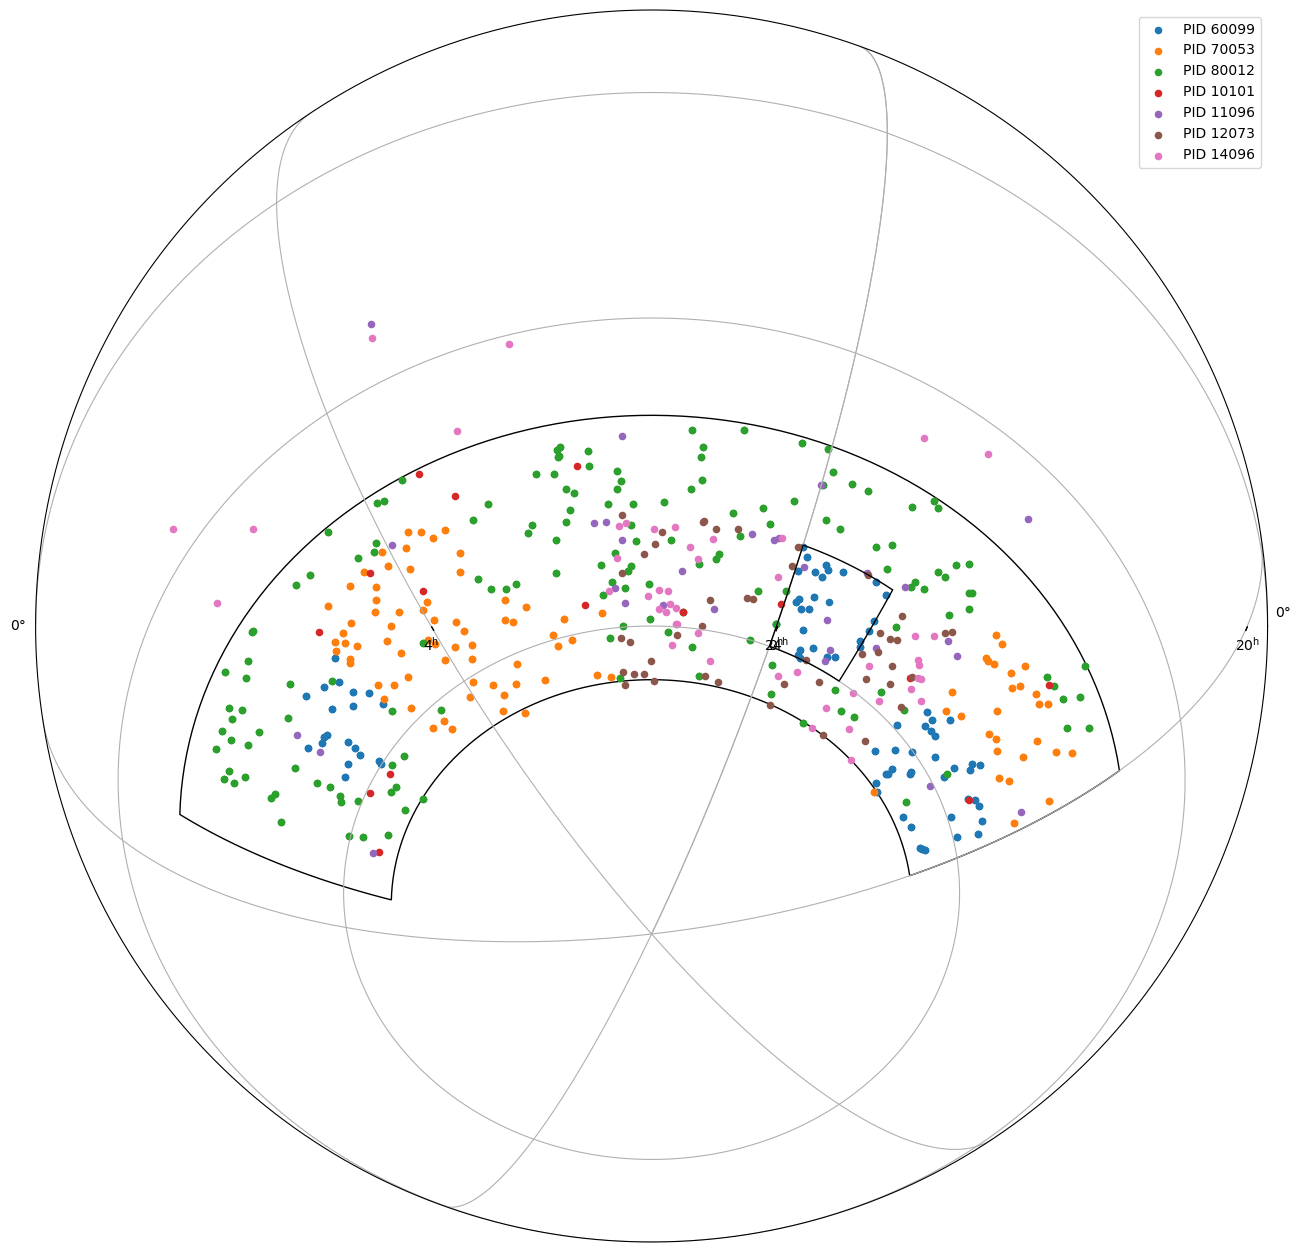

In [10]:
fig, ax = plt.subplots(subplot_kw=globe_opts, figsize=(16,16))
ax.add_patch(Quadrangle(anchor=u.Quantity((300, -65), unit=u.deg), width=spt_sz_width * u.deg, height=25. * u.deg, edgecolor='k', facecolor='none', transform=ax.get_transform('world')))
ax.add_patch(Quadrangle(anchor=u.Quantity((345, -60), unit=u.deg), width=15 * u.deg, height=10 * u.deg, edgecolor='k', facecolor='none', transform=ax.get_transform('world'), zorder=5))
# ax.scatter_coord(irac_pointing_coords, marker='.', s=10)
ax.scatter_coord(irac_pointing_coords_c6, marker='o', s=20, label='PID 60099')
ax.scatter_coord(irac_pointing_coords_c7, marker='o', s=20, label='PID 70053')
ax.scatter_coord(irac_pointing_coords_c8, marker='o', s=20, label='PID 80012')
ax.scatter_coord(irac_pointing_coords_c10, marker='o', s=20, label='PID 10101')
ax.scatter_coord(irac_pointing_coords_c11, marker='o', s=20, label='PID 11096')
ax.scatter_coord(irac_pointing_coords_c12, marker='o', s=20, label='PID 12073')
ax.scatter_coord(irac_pointing_coords_c14, marker='o', s=20, label='PID 14096')
ax.grid()
ax.legend()
fig.savefig('Data_Repository/Project_Data/SPT-IRAGN/Publication_Plots/SPT-IRAC_campaign_footprint_DRAFT.pdf')

In [11]:
all_aors[irac_pointing_coords.dec.argmin()]

targetname,raj2000,decj2000,pi,progid,reqkey,reqtitle
str24,float64,float64,str16,int64,int64,str28
SPT-CLJ0153-6525,28.48741667,-65.4243,"Bleem, Lindsey E",12073,58965248,C12 - SPT-CLJ0153-6525
